# Module 4 - Expanding Your AI Toolkit: Classification Models and Advanced Pipeline Techniques

## Project Kickoff

### Problem Statement

Housing and Development Board (HDB) flats remain the cornerstone of public housing in Singapore, providing affordable living spaces for a significant portion of the population. These high-quality flats come in various sizes and are spread across different towns in Singapore, each offering unique amenities and characteristics. 🏠

The resale market for HDB flats continues to play a crucial role in Singapore's real estate landscape. Resale flats, sold by existing owners in the open market, offer opportunities for Singaporeans to purchase homes in desired locations, often at more competitive prices compared to private housing. The value of these flats is influenced by numerous factors, including flat type, location, floor area, storey, and remaining lease period.

Cataria Property Solutions, a leading real estate company in Singapore, has been using your AI models to predict exact resale prices of HDB flats. However, they've identified a new business need and want to pivot the project in a different direction.

Cataria has observed that their clients often struggle with understanding whether a flat is priced competitively in the current market. Instead of precise price predictions, they now want a simpler classification: Is a flat priced above or below the median market price?

Your new task is to develop machine learning models that can accurately classify HDB resale flats as either above or below the median price. This binary classification task will help potential buyers and sellers quickly understand the relative value of a flat in the resale market.

### Data Dictionary

As you embark on this classification task, let's briefly revisit an important resource you're already familiar with from the regression topic: the data dictionary 📖.

Remember, the data dictionary is your comprehensive guide to the dataset, providing detailed information about each field, including its name and description. If you need a refresher on most of the fields, feel free to refer back to the data dictionary shown below.

For this classification task, there's one crucial update to the data dictionary: The target variable has changed from 'resale_price' to 'price_category'. The new target variable 'price_category' is a binary category indicating whether the resale flat's price is above (1) or below (0) the median price. This change transforms our problem from a regression task (predicting the exact resale price) to a binary classification task. In a classification task, the goal is to predict which predefined category or class a given instance belongs to, based on its features. In our case, we're predicting whether a flat's price falls above or below the median price, effectively categorising each flat prediction into one of two classes.

As you work on this new challenge, keep in mind how this change affects your approach to data analysis and model building. The meaning and interpretation of other variables remain the same as in the previous regression task.

| Field | Description |
|---|---|
| id | Unique identification number |
| month | Year and month that registered the resale price |
| flat_type | Number of bedrooms the resale flat has |
| block | Block number of the resale flat |
| street_name | Street name where the resale flat is located |
| storey_range | Floor level (range) of the resale flat |
| floor_area_sqm | Floor area of the resale flat in square meters |
| lease_commence_date | Commencement year of the flat unit's 99-year lease |
| remaining_lease | Remaining years until the resale flat expires |
| price_category | Whether the resale flat's price is above (1) or below (0) the median price |
| town_id | Number identification of the HDB town where the resale flat is located |
| flatm_id | Number identification of the HDB design model of the resale flat |
| town_name | HDB town where the resale flat is located |
| flatm_name | HDB design model of the resale flat |

Download Resources

To get started with the project, please download the necessary resources from the link provided below:

1. Classification Code Repository

The template classification code repository includes the categorised HDB resale prices dataset, starter files and a structured folder layout to help you organise your work efficiently.

Download this: [Classification Code Repository](https://cdn.lumino.aisg.sg/aiapfoundation/classification.zip)

## Data Understanding and Preparation

Before You Start 🚀
This new module will build on the skills and techniques you mastered earlier. While the flow will feel familiar, you’ll now have more freedom to apply what you’ve learned in new contexts. Here are some key reminders:

1. Preview the Content 👀

Take a quick read through each unit (each unit is a single page 📄) from top to bottom. This will give you a general overview and help you understand the flow of topics covered.

2. Check for Setup Instructions 🔧

At the end of each unit/page, you’ll find a section with instructions to set up your coding environment and install any necessary libraries. Make sure to complete these steps before you start coding.

3. Start Coding Along 💻

Once you’ve set up your environment, head back to the beginning of the unit/page and start coding along with the exercises. Unlike before, not every piece of code will be provided for you. This time, you’ll be expected to integrate the techniques you’ve learned before at the appropriate places in your project. Fill in the code where necessary, and take the opportunity to experiment and explore on your own.

Embrace this new challenge and push your limits! The skills you build by tackling difficult tasks are the ones that will set you apart. Remember, growth happens outside your comfort zone—so dive in and give it your all!🔥

### Understanding the Target Variable

Before diving into the complexities of our classification task, it's crucial to begin with an exploration of our target variable, 'price_category'.

By examining the target variable first, we can immediately see how our data is distributed between the two categories (above and below median price). This distribution is key to understanding our dataset's nature and informs us of the balance (or imbalance) between the two categories. It affects how we approach our classification task which can significantly impact our choice of data preparation techniques, modeling strategies and evaluation metrics.

Assuming that you have performed preliminary data exploration and dropped the duplicated rows, let's visualise the distribution of the target variable. We'll use a simple yet effective univariate analysis technique: a bar chart of the 'price_category' variable. This chart will show us at a glance how many flats fall into each price category (above or below the median price).

The code below does the following:

Create the Bar Chart: Using Seaborn's countplot function, we create a bar chart for the 'price_category' column in our DataFrame. The plot's size is set with figsize, and labels and titles are added for clarity.

Annotate the Bars: We add annotations to each bar to display the frequency count directly on the chart for better readability.

#### Code Input:
```python
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for price category with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='price_category', data=df, palette='pastel')
plt.title('Count of Flats in Each Price Category (Target)')
plt.xlabel('Price Category')
plt.ylabel('Count')
#plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()
```

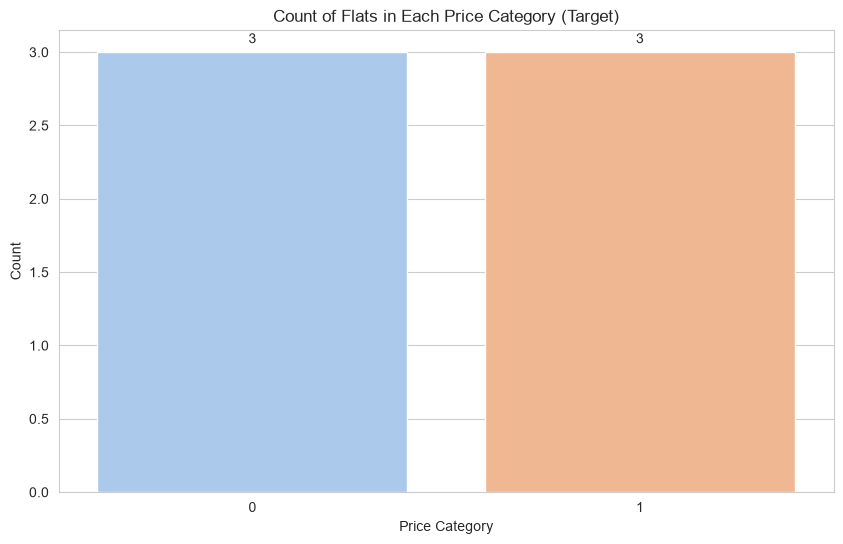

In [9]:
import seaborn as sns
import pandas as pd

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for price category with annotations
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# Ensure the dataframe exists before plotting
if 'df' not in globals():
    try:
        df = pd.read_csv('data/resale_transactions_categorised.csv')  # update path if needed
    except FileNotFoundError:
        df = pd.DataFrame({'price_category': [0, 1, 0, 1, 1, 0]})

count_plot = sns.countplot(
    x='price_category',
    data=df,
    hue='price_category',
    palette='pastel',
    legend=False
)
plt.title('Count of Flats in Each Price Category (Target)')
plt.xlabel('Price Category')
plt.ylabel('Count')
#plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

#### Code Output:

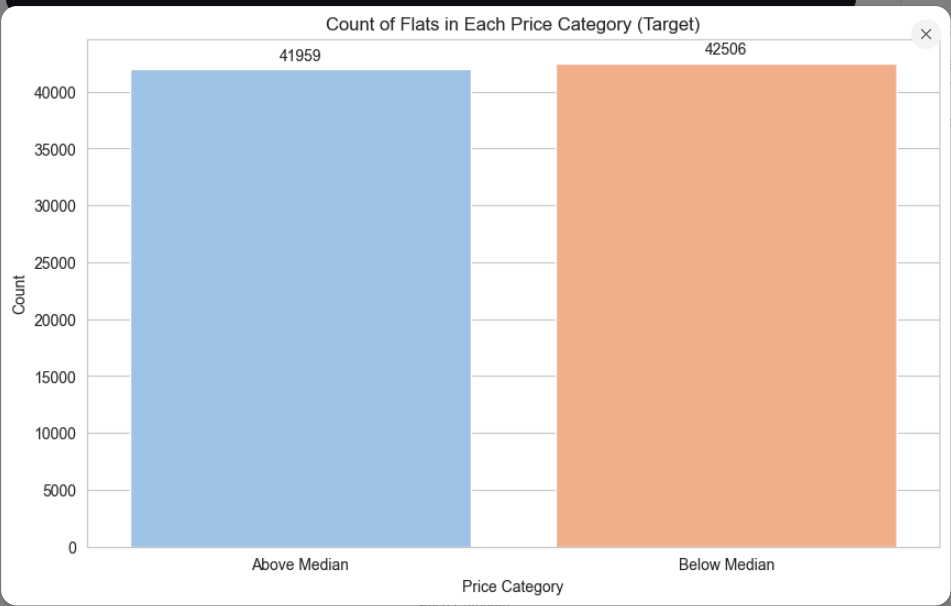

After examining the resulting bar chart above, we can observe a nearly balanced distribution of the two categories in the 'price_category' target variable. We have 42506 flats below the median price and 41959 flats above the median price. This is a remarkably balanced distribution, with only a slight difference of 547 more flats in the "Below Median" category. This near 50-50 split indicates a well-balanced dataset. This balanced distribution is advantageous for training our classification models later. It means that the models will have ample examples from both categories to learn from, reducing the risk of bias towards one class.



### Preparing the Target Variable

Before we can implement any machine learning models, we need to ensure that our target variable is properly encoded for binary classification. In our case, the target variable is 'price_category', which indicates whether a flat's price is above or below the median. This column needs to be converted into a binary format that the classification models can work with.

The code below does the following:

Encode Target Variable: We use the map function to convert the 'price_category' values into numerical binary values. Specifically, we map: 'Above Median' to 1 and 'Below Median' to 0. This encoding transforms the categorical labels into binary numerical values, which are suitable for machine learning models.

Checking the Distribution: After encoding, we use the 'value_counts' function to check the distribution of the target column. This step helps us understand the balance between the two classes (Above Median and Below Median) in the dataset.

#### Code Input:

```python
# Encode the target column
df['price_category'] = df['price_category'].map({'Above Median': 1, 'Below Median': 0})

# Check the distribution of the target column
df['price_category'].value_counts()
```

In [11]:
# Encode the target column
df['price_category'] = df['price_category'].map({'Above Median': 1, 'Below Median': 0})

# Check the distribution of the target column
df['price_category'].value_counts()

Series([], Name: count, dtype: int64)

#### Code Output:

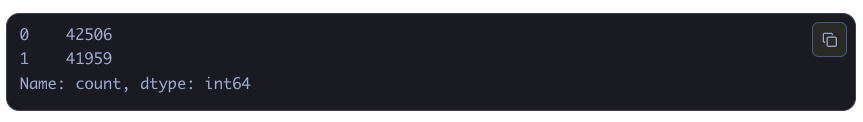

#### Stratified Data Splitting

In our earlier regression task, you might have noticed that we did not use the stratify parameter for the ['train_test_split'](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function because our target variable was continuous. However, for classification tasks, it is important to use stratified splitting to ensure that each split of the dataset maintains the same proportion of classes as the original dataset. This helps preserve the distribution of the target classes in the training, validation, and test sets, which is important for building a reliable and unbiased classification model.

Stratified splitting is a method of dividing data into training, validation, and test sets in such a way that each set has approximately the same percentage of samples of each target class as the original dataset. This is particularly important for classification problems where the target variable is categorical.

Stratification ensures that the class distribution in the training, validation, and test sets is similar to the original dataset. This is essential for training a balanced model that performs well across all classes. Without stratification, there is a risk that one of the sets might have an imbalanced class distribution, leading to a biased model that performs poorly on the minority class.

Let's implement stratified data splitting. The code below does the following:

Importing Module: First, import the necessary 'train_test_split' module for splitting the dataset

Create X and y: The dataset is separated into features (X) and target variable (y). Here, X contains all columns except 'price_category', and y contains the 'price_category' column.

Train-Validation-Test Split: The data is split into training, validation, and testing sets using the 'train_test_split' function. The stratify parameter is set to ensure that the proportion of the classes in y is maintained in all the sets.

##### Code Input:

```python
from sklearn.model_selection import train_test_split

# Separate the data into features and target
X = df.drop(columns='price_category')
y = df['price_category']

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
```

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the data into features and target
X = df.drop(columns='price_category')
y = df['price_category']

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

##### Revisiting EDA, Data Cleaning and Preprocessing

As you embark on this classification task, you'll be working with a dataset that should feel familiar. You've already gained valuable experience with Exploratory Data Analysis (EDA), data cleaning and preprocessing in the previous regression task. Now, it's time to put those skills into practice independently. 🔍📊🧹

The good news is that the underlying data remains largely unchanged. The only significant difference is the transformation of our target variable from 'resale_price' to 'price_category'. This means that much of your previous data exploration and preparation steps will still apply. As you proceed with your analysis, take some time to reflect on how the shift from a continuous 'resale_price' to a binary 'price_category' target variable affects your approach and interpretation.

While we won't be repeating the step-by-step guidance for EDA and data preparation in this course, we expect you to still apply these crucial skills on your own in the provided code repository. Remember, thorough EDA and proper data preparation are the foundation of any successful machine learning project. Your efforts here will pay dividends when you start building your classification models.

#### Coding Exercise 💻

Now, it's your turn to fully understand and prepare your dataset for classification! Using the techniques you’ve learned earlier, apply the code to perform a thorough exploratory data analysis (EDA), data cleaning, and preprocessing. Remember to adjust the code as necessary for this dataset. Be thorough in your analysis and critical in your decision-making process. Follow the instructions below:

1. Open VSCode:

Launch Visual Studio Code (VSCode) on your computer.

2. Open Jupyter Notebook:

Navigate to the template code repository and open the file eda.ipynb

3. Activate Your Conda Environment:

Open the terminal in VSCode (you can open it via View > Terminal). Activate your conda environment named hdbenv by typing the following command:

```conda activate hdbenv```

4. Start Coding:

Using the code snippets provided earlier, ensure that you fully grasp your data and prepare it optimally before moving on to modeling.

## Model Development - Developing Classification Models

### Logistic Regression

#### What is Classification?

Imagine you're scrolling through your email inbox. In a split second, your brain decides whether each email is important, spam, or just another newsletter. Without even realising it, you're performing classification – a fundamental task in machine learning that we're about to dive into!

At its heart, classification is about making decisions. It's the art of looking at a set of features and saying, "This belongs in Category A" or "That fits into Category B." 

In our journey through the Singapore housing market, we're taking on an exciting challenge: predicting whether a HDB resale flat's price is above or below the median. It's like being a real estate expert who can quickly assess whether a property is a bargain or a luxury!

In this course, we'll focus on three powerful and widely-used classification algorithms; logistic regression, k-nearest neighbours, and decision trees. Remember, while we're focusing on these three algorithms, there are many other classification techniques out there, each with its own unique advantages. The skills you learn here will provide a solid foundation for exploring more advanced classification methods in the future.

1. Logistic Regression

Despite its name, logistic regression is a classification algorithm. It's often the starting point for binary classification problems, providing a straightforward approach to predicting probabilities of class membership.

2. K-Nearest Neighbors (KNN)

KNN is an intuitive algorithm that classifies observations based on the majority class of their nearest neighbours in the feature space. It's a non-parametric method that can capture complex decision boundaries.

3. Decision Trees

Decision trees, another non-parametric algorithm, make predictions by following a series of decisions based on the features. They're highly interpretable and can handle both numerical and categorical data effectively.

#### Univariate Logistic Regression

Logistic regression, despite its name, is actually used for classification problems. It's particularly useful when predicting one of two possible outcomes - in our case, whether a flat's price is above (1) or below (0) the median. This type of problem, where we have two possible categories, is called binary classification.

Let's start simple with univariate logistic regression. "Univariate" means we're using just one feature to make our prediction.

For example, let's say we want to predict if a flat's price is above or below the median based solely on its floor area. In our HDB dataset, we can see that 'floor_area_sqm' varies quite a bit - from small 31 sqm flats to spacious 280 sqm units.

Logistic regression would analyse this data and create a model that predicts the likelihood of a flat being priced above the median based on its floor area. The logistic regression model provides a probability rather than a binary yes or no answer. For instance, it might say: "A 100 sqm flat has a 75% chance of being priced above the median." 🎲

Here’s an intuitive breakdown of how univariate logistic regression works.

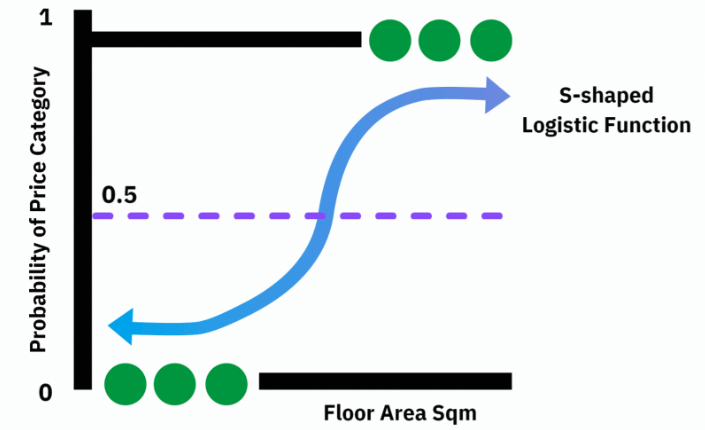

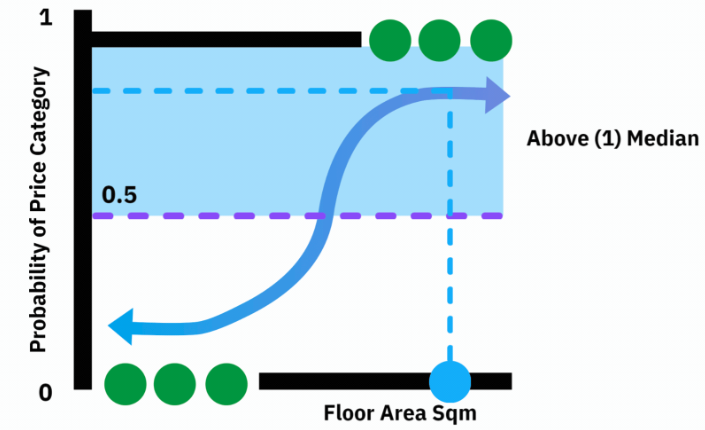

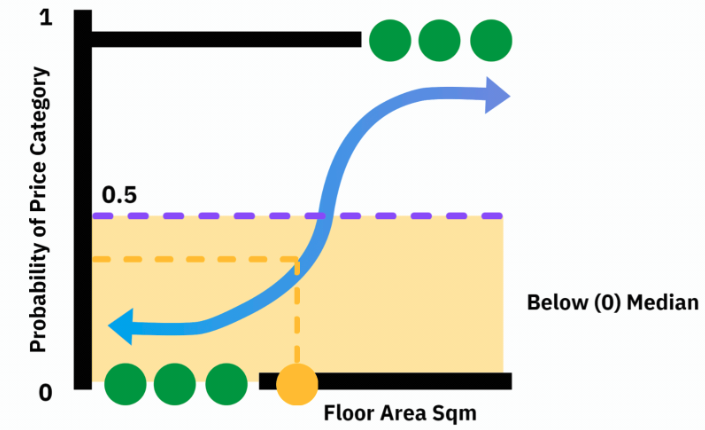

1. Logistic Function

Logistic regression uses a special S-shaped curve called the logistic function (or sigmoid function) to model the probability of an outcome. The output of the logistic function is always between 0 and 1, which makes it suitable for probability estimation. In our case, it models the probability that a flat's price is above the median based on its floor area.

2. Model Behavior

As the floor area increases, the probability of the price being above the median generally increases, but not in a straight line. For very small flats, the probability of being above the median price is close to 0%. For very large flats, the probability of being above the median price is close to 100%. In between, there’s a “sweet spot” where a small change in floor area can significantly change the probability. The S-shape of the logistic function captures this relationship perfectly. It starts off flat for small values, rises steeply in the middle, and flattens out again for large values.

3. Decision Threshold

In logistic regression, the output of the logistic function (sigmoid function) is a probability that ranges between 0 and 1. When the logistic function outputs a probability, you need a threshold to decide which class the instance belongs to. A common threshold is 0.5. If the probability is greater than or equal to 0.5, the instance is classified as the positive class (1), meaning the flat's price is predicted to be above the median. If the probability is less than 0.5, the instance is classified as the negative class (0), meaning the flat's price is predicted to be below the median. This threshold can be adjusted depending on the specific needs of the problem statement and context.

#### Multivariate Logistic Regression

Multivariate logistic regression extends the basic concept of univariate logistic regression to include multiple features. Instead of predicting whether a resale flat's price is above or below the median based solely on its floor area, we now consider various other features in our HDB dataset, such as the number of rooms, flat model type, and location. For example, two flats might have the same floor area, but one could be in a more desirable location, affecting its price. Multivariate logistic regression allows us to account for these differences by including additional features in the model.

In multivariate logistic regression, the logistic function is extended to incorporate multiple features (X₁, X₂, ..., Xₙ). The model equation becomes:

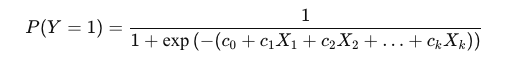

$
P(Y = 1) = \frac{1}{1 + \exp\left(-(c_0 + c_1 X_1 + c_2 X_2 + \ldots + c_k X_k)\right)}
$

**where:**

- $P(Y=1)$ is the probability of the event occurring (e.g., being above the median price).
- $\exp$ is the base of the natural logarithm.
- $c_0$ is the intercept term.
- $c_1, c_2, \ldots, c_k$ are the coefficients of the features or predictor variables $X_1, X_2, \ldots, X_k$.

Here, $c_0$ is the intercept, and $c_1, c_2, \ldots, c_n$ are the coefficients for the respective features. 

Each coefficient ($c_1, c_2, \ldots, c_n$) represents the change in the log odds of the target variable for a one-unit change in the corresponding feature, holding all other features constant. 

Log odds is a way of expressing the probability of an event occurring versus it not occurring, transforming probabilities from 0 to 1 into a scale ranging from negative infinity to positive infinity. 

For instance, if $c_1$ is positive, an increase in $X_1$ (e.g., floor area) increases the likelihood of the flat's price being above the median.

Similar to univariate logistic regression, multivariate logistic regression uses a decision threshold to classify the outcome. A common threshold is 0.5, meaning if the predicted probability is greater than or equal to 0.5, the flat is classified as having a price above the median; otherwise, it is classified as below the median. In multivariate logistic regression, the decision threshold that separates the classes is not a simple line as in the univariate case but could be a plane or a hyperplane depending on the number of predictors. ✈️

#### Implementing Multivariate Logistic Regression

Before we proceed, remember that you should prepare the target variable, split the data with stratification, and set up the proper preprocessor pipelines. Now it's time to take the next step: implementing multivariate logistic regression.

The code below does the following:

Import Modules: Import Logistic Regression model from Sklearn's linear models module.

Create the Pipeline: We use the Pipeline class from sklearn.pipeline to chain the preprocessing steps and the logistic regression model together. The preprocessor pipeline (preprocessor) defined earlier is included in the pipeline to handle data transformations. The logistic regression model is instantiated with the LogisticRegression class from sklearn.linear_model, with the maximum number of iterations (max_iter) set to 1000 to ensure convergence.

Fit and Predict: The fit method is called on the pipeline, using the training data (X_train and y_train). This method trains the logistic regression model on the preprocessed data. After training the model, we use the predict method to make predictions on the validation set (X_val). This method returns the predicted class labels for the validation data.

##### Code Input:
```python
# Import the necessary library
from sklearn.linear_model import LogisticRegression

# Create the pipeline with a logistic regression model
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Use the preprocessor pipeline defined earlier
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
logreg_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = logreg_pipeline.predict(X_val)
```


In [ ]:
# Import the necessary library
from sklearn.linear_model import LogisticRegression

# Create the pipeline with a logistic regression model
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Use the preprocessor pipeline defined earlier
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
logreg_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = logreg_pipeline.predict(X_val)

Now, let's inspect the pipeline object we created, which includes the Logistic Regression model. The 'logreg_pipeline' object now encapsulates both the preprocessing steps and the logistic regression model, allowing you to apply the entire process in a single, streamlined operation. You may interact with the diagram below by clicking each component to explore its details

Code Input:
```python
logreg_pipeline
```

##### Code Output:

_Pipeline_

```python
Pipeline(steps=[('preprocessor',
    ColumnTransformer(n_jobs=-1, remainder='passthrough',
        transformers=[('num',
            Pipeline(steps=[('scaler', StandardScaler())]),
            ['floor_area_sqm', 'remaining_lease_months',
             'lease_commence_date', 'year']),
        ('nom',
            Pipeline(steps=[('onehot', OneHotEncoder())]),
            ['month', 'town_name', 'flatm_name']),
        ('ord',
            Pipeline(steps=[('ordinal',
                OrdinalEncoder(categories=[['1 ROOM', '2 ROOM', 
                '3 ROOM', '4 ROOM', '5 ROOM', 
                'MULTI-GENERATION', 'EXECUTIVE']]))]),
            ['flat_type']),
        ('pass', 'passthrough', ['storey_range'])])),
    ('classifier', LogisticRegression(max_iter=1000))])
```

In [ ]:
Pipeline(steps=[('preprocessor',
    ColumnTransformer(n_jobs=-1, remainder='passthrough',
        transformers=[('num',
            Pipeline(steps=[('scaler', StandardScaler())]),
            ['floor_area_sqm', 'remaining_lease_months',
             'lease_commence_date', 'year']),
        ('nom',
            Pipeline(steps=[('onehot', OneHotEncoder())]),
            ['month', 'town_name', 'flatm_name']),
        ('ord',
            Pipeline(steps=[('ordinal',
                OrdinalEncoder(categories=[['1 ROOM', '2 ROOM', 
                '3 ROOM', '4 ROOM', '5 ROOM', 
                'MULTI-GENERATION', 'EXECUTIVE']]))]),
            ['flat_type']),
        ('pass', 'passthrough', ['storey_range'])])),
    ('classifier', LogisticRegression(max_iter=1000))])

_preprocessor: ColumnTransformer_

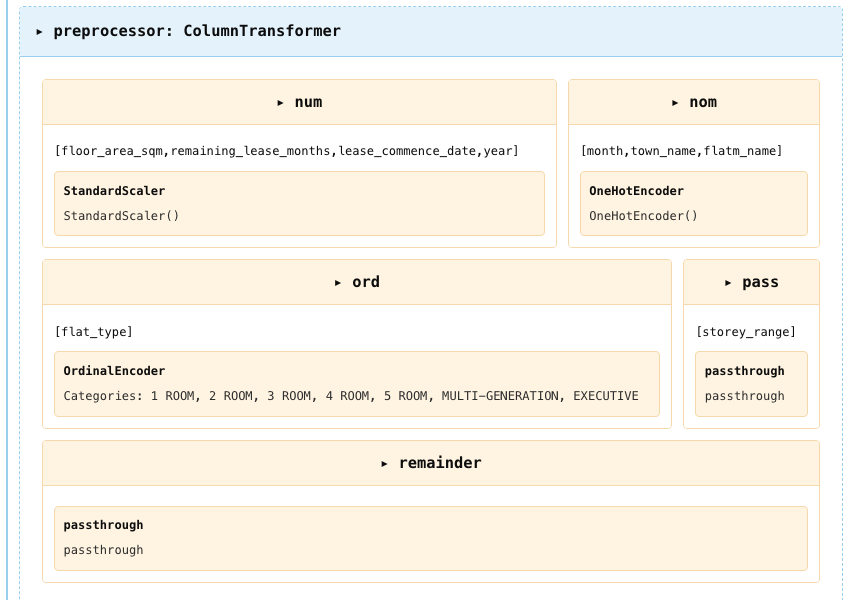

_LogisticRegression_

LogisticRegression
LogisticRegression(max_iter=1000)

## Model Evaluation

After building your classification model, it's crucial to evaluate its performance. Model evaluation helps us understand how well our model is doing and where it might need improvement. Since classification has many more metrics than regression, we will explain the metrics and corresponding terminology step by step.

We'll work through the metrics for classification together in the structure outlined below.

1. Accuracy and Confusion Matrix

We'll start with accuracy, the most intuitive metric. Then, we'll introduce the confusion matrix, which provides a detailed breakdown of where your model is making correct and incorrect predictions. We'll explain how accuracy can be calculated from the confusion matrix.

2. Precision, Recall and F1 Score

Next, we'll delve into precision and recall, two important metrics also derived from the confusion matrix. We'll discuss when each metric is particularly important, such as precision for spam detection and recall for medical diagnoses. We'll show how to calculate precision and recall from the confusion matrix. We'll also introduce the F1 score, a metric that balances precision and recall. We'll explain why balancing these metrics can be important in certain scenarios.

3. ROC Curve and AUC

Finally, we'll cover more advanced evaluation metrics like the ROC curve and AUC. We'll explain how these metrics paint a more complete picture of your model's performance across different thresholds.

By breaking down the metrics step by step, you'll gain a comprehensive understanding of how to evaluate your classification models effectively. Let's get started!

### Accuracy 🎯

Accuracy is the most intuitive and simplest metric to understand. It measures the proportion of correct predictions (both true positives and true negatives) among the total number of cases examined. Accuracy is a good measure when your classes are balanced, meaning you have about the same number of samples for each class in the target variable. In such cases, it provides a clear picture of how well your model is performing overall.

The formula for calculating accuracy is:

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

Let's calculate accuracy for our Logistic Regression model using the validation set. The code below does the following:

Import Modules: Imports the necessary metrics from sklearn.metrics that will be used to evaluate the performance of the Logistic Regression model. The metrics imported are 'accuracy_score', 'precision_score', 'recall_score', and 'f1_score'. We will be using the other metrics later.

Calculate Accuracy: Calculates the accuracy score of the Logistic Regression model on the validation set. The 'accuracy_score' function takes two arguments: the true labels (y_val) and the predicted labels (y_val_pred). It returns the proportion of correctly classified samples.

Display the Calculated Metric: Print the calculated accuracy score for the Logistic Regression model.

#### Code Input:

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the classification metrics for Logistic Regression
logreg_val_accuracy = accuracy_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Accuracy: {logreg_val_accuracy:.5f}')
```

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate the classification metrics for Logistic Regression
logreg_val_accuracy = accuracy_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Accuracy: {logreg_val_accuracy:.5f}')

#### Code Output:

Logistic Regression Metrics:
LogReg Validation Accuracy: 0.89190

In this example, the Logistic Regression model achieved an accuracy of 0.89190, meaning it correctly predicted the class for approximately 89.19% of the samples in the validation set as either above or below the median price. This is a good indication that the model is performing well.

However, an important limitation of the accuracy metric is that it can be misleading if the number of classes in the target variable are imbalanced. For instance, if 90% of your flats were below the median price, a model that always predicts "below median" would have 90% accuracy, but it wouldn't be very useful.

### Confusion Matrix 🌀

A confusion matrix is a fundamental tool for evaluating the performance of a classification model. It provides a detailed breakdown of the model's performance by showing the number of correct and incorrect predictions, categorised by actual and predicted classes.

The confusion matrix for a binary classification problem typically looks like this:

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | True Negative (TN) | False Positive (FP) |
| **Actual Positive** | False Negative (FN) | True Positive (TP) |

- True Negative (TN): The number of correct predictions where the actual class is negative and the model rightly predicted the class as also negative.
- False Positive (FP): The number of incorrect predictions where the actual class is negative, but the model wrongly predicted the class as positive.
- False Negative (FN): The number of incorrect predictions where the actual class is positive, but the model wrongly predicted the class as negative.
- True Positive (TP): The number of correct predictions where the actual class is positive and the model rightly predicted the class as also positive.

Let's create the confusion matrix from the results of the Logistic Regression model.

The code below does the following:

Import Modules: The 'confusion_matrix' function from sklearn.metrics calculates the confusion matrix, and 'ConfusionMatrixDisplay' helps in visualising it. 'matplotlib.pyplot' is imported for plotting the matrix.

Calculate the Confusion Matrix: 'confusion_matrix(y_val, y_val_pred)' computes the confusion matrix based on the true labels (y_val) and predicted labels (y_val_pred).

Create Display Object: 'ConfusionMatrixDisplay(confusion_matrix=cm)' creates a display object for the confusion matrix cm.

Plot the Confusion Matrix: 'disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)' plots the confusion matrix display object on the specified axes (ax) with a blue color map (cmap=plt.cm.Blues). The colorbar=False argument hides the color bar.

#### Code Input:

```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()
```

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

#### Code Output"

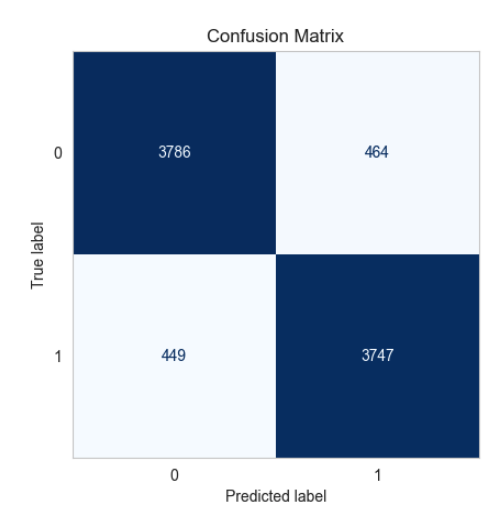

With the validation results of the Logistic Regression model plotted in the confusion matrix above, let's break down the numbers and interpret them.

TN = 3786: The model correctly predicted 3786 flats as below median price.
FP = 464: The model incorrectly predicted 464 flats as above median when they were actually below.
FN = 449: The model incorrectly predicted 449 flats as below median when they were actually above.
TP = 3747: The model correctly predicted 3747 flats as above median price.
This matrix shows that your model is performing quite well, with a high number of correct predictions (TN and TP) compared to incorrect predictions (FP and FN).

Now that we understand what each number in the confusion matrix represents, we can use this information to calculate various metrics. Let's start with accuracy, which we discussed earlier.

Remember, accuracy is the proportion of correct predictions among the total number of cases examined. In terms of the confusion matrix, correct predictions are represented by True Negatives (TN) and True Positives (TP), while the total number of cases is the sum of all values in the matrix.


$$
\text{Accuracy} = \frac{TN + TP}{TN + FP + FN + TP}
$$


$$
\text{Accuracy} = \frac{3786 + 3747}{3786 + 464 + 449 + 3747} \approx 0.8919
$$

This calculation matches the accuracy score we obtained earlier using sklearn's 'accuracy_score' function.

### Precision, Recall, and F1 Score

After evaluating accuracy, it is important to delve into more specific metrics that can provide a deeper understanding of your model's performance, especially in imbalanced datasets. These metrics include precision, recall, and F1 score. Let's explore how to calculate them using your Logistic Regression model's results, what these metrics are, and why they are important.

Let's start by calculating the scores of all three metrics. The code below does the following:

Calculate Precision: 'precision_score' is a function from sklearn.metrics used to calculate the precision of a classification model. 'y_val' is the true labels (actual values) of the validation set. 'y_val_pred' is the predicted labels from the Logistic Regression model for the validation set.
Calculate Recall: 'recall_score' is a function from sklearn.metrics used to calculate the recall of a classification model.
Calculate F1 Score: 'f1_score' is a function from sklearn.metrics used to calculate the F1 score of a classification model.
Display the Calculated Metrics: Print the calculated scores for the Logistic Regression Model


#### Code Input:

```python
# Calculate the classification metrics for Logistic Regression
logreg_val_precision = precision_score(y_val, y_val_pred)
logreg_val_recall = recall_score(y_val, y_val_pred)
logreg_val_f1 = f1_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Precision: {logreg_val_precision:.5f}')
print(f'LogReg Validation Recall: {logreg_val_recall:.5f}')
print(f'LogReg Validation F1 Score: {logreg_val_f1:.5f}')
```

In [ ]:
# Calculate the classification metrics for Logistic Regression
logreg_val_precision = precision_score(y_val, y_val_pred)
logreg_val_recall = recall_score(y_val, y_val_pred)
logreg_val_f1 = f1_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Precision: {logreg_val_precision:.5f}')
print(f'LogReg Validation Recall: {logreg_val_recall:.5f}')
print(f'LogReg Validation F1 Score: {logreg_val_f1:.5f}')

#### Code Output:

Logistic Regression Metrics:

LogReg Validation Precision: 0.88981

LogReg Validation Recall: 0.89299

LogReg Validation F1 Score: 0.89140

Now, with the evaluation metrics obtained from the sklearn functions, let's explore how we can calculate them directly from the confusion matrix. We will also discuss their interpretations and situations where each metric is particularly important.

#### Precision 📍

Precision is the ratio of correctly predicted positive observations to the total predicted positives. It answers the question: "What proportion of predicted positives are actually correct?"

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

*For our HDB dataset:* 
$$
\text{Precision} = \frac{3747}{3747 + 464} = \frac{3747}{4211} \approx 0.88981
$$

Interpretation: About 88.98% of the flats predicted to be above median price are actually above median.

Importance: Precision is critical when the cost of false positives is high. For example, in spam detection, a false positive means a legitimate email is marked as spam, which might cause the user to miss important emails.

Example: In spam detection, high precision ensures that most of the emails marked as spam are indeed spam, minimising the risk of missing important emails.


#### Recall 🧲

Recall (or Sensitivity) is the ratio of correctly predicted positive observations to all observations in actual class. It answers the question: "What proportion of actual positives was correctly identified?"

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**For our HDB dataset:**

$$
\text{Recall} = \frac{3747}{3747 + 449} = \frac{3747}{4196} \approx 0.89299
$$

**Interpretation:** About 89.30% of the flats that are actually above median price were correctly identified by the model.

**Importance:** Recall is crucial when the cost of false negatives is high. For example, in medical diagnoses, a false negative means a sick patient is classified as healthy, which can have severe consequences.

**Example:** In cancer detection, high recall ensures that most of the actual cancer cases are identified, minimising the risk of missing a diagnosis.

#### F1 Score ⚖️

The F1 Score is the harmonic mean of Precision and Recall. It is useful when you need a balance between Precision and Recall and there is an uneven class distribution.

$$
\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**For our HDB dataset:**

$$
\text{F1 Score} = 2 \times \frac{0.88981 \times 0.89299}{0.88981 + 0.89299} \approx 0.89140
$$

**Interpretation:** The F1 Score is approximately 0.89140, indicating a good balance between precision and recall for our classification model.

**Importance:** The F1 score is important when you need to balance precision and recall. It is useful when the class distribution is imbalanced and the costs of false positives and false negatives are equally high.

**Example:** In a hiring process, an F1 score provides a balanced measure by considering both precision (minimising false positives where unqualified candidates are selected) and recall (minimising false negatives where qualified candidates are overlooked). This balance ensures that the hiring process is both effective and fair.

#### Receiver Operating Characteristic (ROC) Curve and Area Under Curve (AUC)

In binary classification tasks, one of the key decisions is selecting an appropriate threshold to distinguish between the positive and negative classes. The default threshold is typically set at 0.5. This means that if the predicted probability of an instance being in the positive class is greater than 0.5, it is classified as positive; otherwise, it is classified as negative. In the context of our HDB resale price category dataset, samples with a predicted probability of more than 0.5 are classified as Above Median (➕), while samples with a predicted probability of less than 0.5 are classified as Below Median (➖).

Using a single threshold of 0.5 provides only one point of performance evaluation for our model, a single confusion matrix which you saw above. This can be limiting because it does not consider how the model performs at different threshold settings. If we adjust the threshold from 0 to 1, we can get different confusion matrices. Examining multiple thresholds provides a more complete picture of the model's capabilities. It shows how the model performs under various conditions, from very lenient (low threshold) to very strict (high threshold) classification criteria. This approach would allow us to explore the model's behavior across its entire operating range.

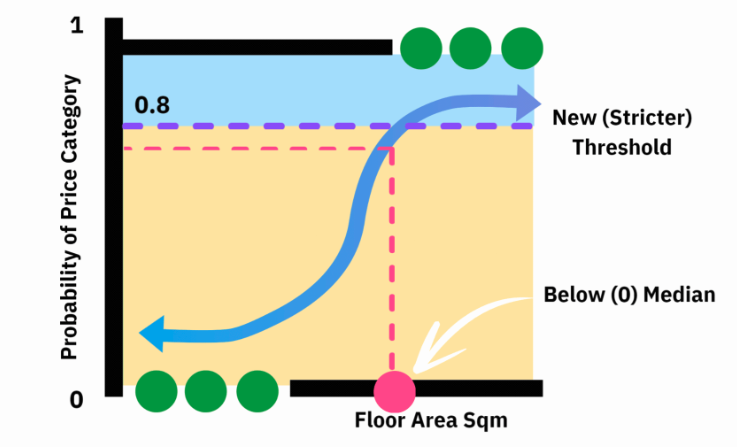

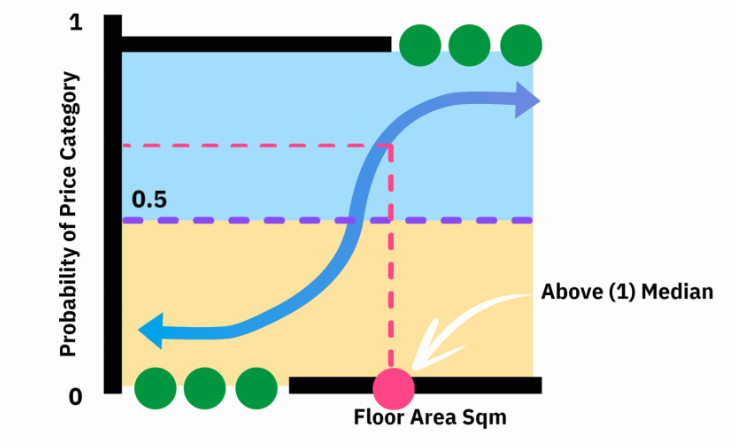


The Receiver Operating Characteristic (ROC) curve is a graphical representation that illustrates the performance of a binary classifier across different threshold values. It plots two key metrics:

**True Positive Rate (TPR):** Also known as Sensitivity or Recall, it measures the proportion of actual positives correctly identified by the model. It tells us what proportion of flats Above Median price were correctly classified. It is calculated as:

$$
\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

**False Positive Rate (FPR):** It measures the proportion of actual negatives incorrectly identified as positives by the model. It tells us the proportion of flats Below Median price that were incorrectly classified as above median by the model. It is calculated as:

$$
\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
$$

Keep in mind that calculating a single set of TPR and FPR comes from one confusion matrix at a specific threshold (currently 0.5). To get a comprehensive view of the model's performance, we need to vary the thresholds and calculate the corresponding TPR and FPR for each. This will allow us to plot the ROC curve. Fortunately, we can easily implement this process with code, so let's proceed with that now.

The code below does the following:

- **Importing Libraries:** `roc_curve` and `roc_auc_score` from `sklearn.metrics` are used to compute the ROC curve and the AUC, respectively. `matplotlib.pyplot` is used for plotting. We'll discuss the AUC shortly.
- **Calculating ROC Curve:** The [`roc_curve`](https://scikit-learn.org/stable/modules/model_evaluation.html#receiver-operating-characteristic-roc) function computes the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for different decision boundaries. The `predict_proba` method gives the predicted probabilities, and 
`[:, 1]` selects the probabilities of the positive class (above median) in the validation set using the trained Logistic Regression model.
- **Calculating AUC:** The `roc_auc_score` function computes the Area Under the ROC Curve (AUC), which provides a single number summary of the classifier's performance.
- **Plot the Curve:** The ROC curve is plotted using `plt.plot(fpr, tpr)`. A red dashed line is added to represent a random guess classifier, which serves as a baseline. The plot is formatted with axis labels, a title, a legend, and a grid.

##### Code Input

```python
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt  

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Calculate the AUC
roc_auc = roc_auc_score(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.xlabel('False Positive Rate (FPR)')  
plt.ylabel('True Positive Rate (TPR)')  
plt.title('Receiver Operating Characteristic (ROC) Curve')  
plt.legend(loc='lower right')  
plt.grid()  
plt.show()
```

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt  

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Calculate the AUC
roc_auc = roc_auc_score(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.xlabel('False Positive Rate (FPR)')  
plt.ylabel('True Positive Rate (TPR)')  
plt.title('Receiver Operating Characteristic (ROC) Curve')  
plt.legend(loc='lower right')  
plt.grid()  
plt.show()

#### Code Output:

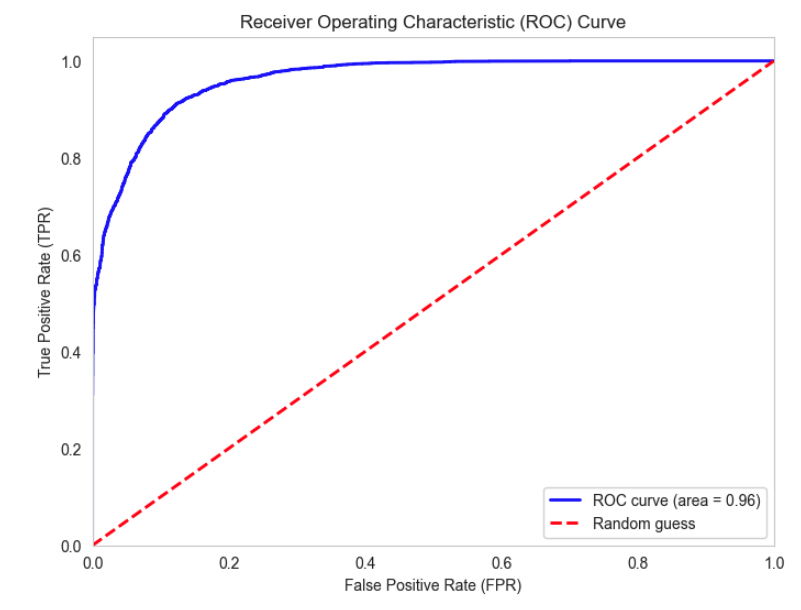

With our ROC curve plotted, let's interpret it in detail. Remember, the ROC curve provides a comprehensive view of our logistic regression model's performance across different threshold settings.

The ROC curve starts at the bottom-left corner (0,0) and rises towards the top-right corner (1,1). The steep initial rise of our ROC curve towards the top-left corner signifies that our model has a high true positive rate and a low false positive rate. This indicates strong performance in distinguishing between flats priced above and below the median. The smooth curve suggests that our model's probability estimates are well-calibrated and consistent across different threshold settings.

The dashed red line represents a random guess, where the model has no discriminative power, with a slope of 1 (a 45-degree line). Any point above this line indicates better-than-random performance, which our Logistic Regression model significantly exceeds.

You may notice that the ROC curve plot displays a single number, 0.96. This is the  AUC, or Area Under the Curve. AUC provides a single scalar value to summarise the ROC curve, quantifying the overall ability of our model to discriminate between positive and negative classes. It ranges from 0 to 1. An AUC of 1 represents perfect model performance. An AUC of 0.5 or below represents no discriminative power, equivalent to random guessing. An AUC of more than 0.5 indicates the model performs better than random guessing.

In our case,  the AUC is 0.96, which is excellent. This high AUC value signifies that our model has a very high ability to distinguish between flats priced above and below the median. Specifically, an AUC of 0.96 means there is a 96% chance that our model will correctly classify a randomly chosen positive instance (above median price) as having a higher probability than a randomly chosen negative instance (below median price).

When you experiment with different classifier models later, you may choose to use the ROC-AUC for quick model performance comparison.

Test